In [ ]:
import pandas as pd
import numpy as np

data={
  'weather':
  ['sunny','sunny','cloudy','rainy','rainy','rainy','cloudy','sunny','sunny','rainy','sunny','cloudy','cloudy','rainy'],

  'tremperture':
  ['hot','hot','hot','mild','cool','cool','cool','mild','cool','mild','mild','mild','hot','mild'],

  'solid moisture':
  ['dry','dry','dry','dry','moist','moist','moist','dry','moist','moist','moist','dry','moist','dry'],

  'wind':
  ['weak','strong','weak','weak','weak','strong','strong','weak','weak','weak','strong','strong','weak','strong'],

  'irrigate':
  ['no','no','yes','yes','yes','no','yes','no','yes','yes','yes','yes','yes','no']
}

df=pd.DataFrame(data)


def entropy(target):
  values,counts=np.unique(target,return_counts=True)
  prob=counts/counts.sum()
  return -np.sum(prob*np.log2(prob))


def information_gain(data,feature,target_name):
  total_entropy=entropy(data[target_name])
  values,counts=np.unique(data[feature],return_counts=True)

  weighted_entropy=0
  for i in range(len(values)):
    subset=data[data[feature]==values[i]]
    weighted_entropy+=(counts[i]/np.sum(counts))*entropy(subset[target_name])

  return total_entropy-weighted_entropy


def id3(data,features,target_name,depth=0):

    indent=" "*depth

    if len(np.unique(data[target_name]))==1:
       return np.unique(data[target_name])[0]

    if len(features)==0:
       return data[target_name].mode()[0]

    gains_list=[]
    print(f"\n{indent}depth={depth}")

    for feature in features:
        current_gain=information_gain(data,feature,target_name)
        gains_list.append(current_gain)
        print(f"{indent}feature={feature},gain={current_gain}")

    best_feature=features[np.argmax(gains_list)]
    print(f"{indent}best_feature={best_feature}")
    tree={best_feature:{}}

    for value in np.unique(data[best_feature]):
        subset=data[data[best_feature]==value]

        if subset.shape[0]==0:
          tree[best_feature][value]=data[target_name].mode()[0]
        else:
          remaining_features=[f for f in features if f!=best_feature]
          subtree=id3(subset,remaining_features,target_name,depth+1)
          tree[best_feature][value]=subtree
    return tree


def print_tree(tree,indent=""):
    if not isinstance(tree,dict):
        print(f"{indent}{tree}")
        return

    for feature,branches in tree.items():
        print(f"{indent}{feature}:")
        for value,subtree in branches.items():
            print(f"{indent}  {value}: ", end="")
            print_tree(subtree,indent+"    ")


features=list(df.columns[:-1])

tree_model=id3(df,features ,'irrigate')

print("\n Final Decision Tree :\n")
print_tree(tree_model)



depth=0
feature=weather,gain=0.24674981977443933
feature=tremperture,gain=0.02922256565895487
feature=solid moisture,gain=0.15183550136234159
feature=wind,gain=0.04812703040826949
best_feature=weather

 depth=1
 feature=tremperture,gain=0.01997309402197489
 feature=solid moisture,gain=0.01997309402197489
 feature=wind,gain=0.9709505944546686
 best_feature=wind

 depth=1
 feature=tremperture,gain=0.5709505944546686
 feature=solid moisture,gain=0.9709505944546686
 feature=wind,gain=0.01997309402197489
 best_feature=solid moisture

 Final Decision Tree :

weather:
  cloudy:     yes
  rainy:     wind:
      strong:         no
      weak:         yes
  sunny:     solid moisture:
      dry:         no
      moist:         yes


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay




np.random.seed(42)
n_samples=60


data={
    "weather":
    np.random.choice(["sunny","cloudy","rainy"],n_samples),

    "tremperture":
    np.random.choice(["hot","mild","cool"],n_samples),

    "soil":
    np.random.choice(["dry","moist"],n_samples),

    "wind":
    np.random.choice(["weak","strong"],n_samples),

    "irrigate":
    np.random.choice(["yes","no"],n_samples),


    "humidity":
    np.random.choice(["high","low"],n_samples),

    "Fertilizer":np.random.choice(["Organic","pesticides"],n_samples),

    "crop type":np.random.choice(["cotton","wheat","rice"],n_samples),

    "season":np.random.choice(["summer","winter"],n_samples)
}

df=pd.DataFrame(data)



def irrigation_rule(row):
  if row['soil']=='dry'and row['weather']!='rainy':
    return 'yes'
  elif row['soil']=='wet':
    return 'no'
  elif row['humidity']=='high':
    return 'yes'
  elif row['humidity']=='low':
    return 'no'
  else:
    return np.random.choice(['yes','no'])

df['irrigation_rule']=df.apply(irrigation_rule,axis=1)

print("sample Dataset:\n",df.head())











sample Dataset:
   weather tremperture   soil    wind irrigate humidity  Fertilizer crop type  \
0   rainy        mild  moist  strong      yes      low     Organic    cotton   
1   sunny         hot    dry  strong      yes     high  pesticides      rice   
2   rainy        mild    dry  strong      yes     high  pesticides      rice   
3   rainy        mild  moist  strong       no      low     Organic    cotton   
4   sunny        mild  moist  strong       no      low     Organic    cotton   

   season irrigation_rule  
0  summer              no  
1  winter             yes  
2  summer             yes  
3  winter              no  
4  summer              no  


In [ ]:
le_dict={}
for column in df.columns:
  le=LabelEncoder()
  df[column]=le.fit_transform(df[column])
  le_dict[column]=le

print("\nEncoded Dataset:\n",df.head())


Encoded Dataset:
    weather  tremperture  soil  wind  irrigate  humidity  Fertilizer  \
0        1            2     1     0         1         1           0   
1        2            1     0     0         1         0           1   
2        1            2     0     0         1         0           1   
3        1            2     1     0         0         1           0   
4        2            2     1     0         0         1           0   

   crop type  season  irrigation_rule  
0          0       0                0  
1          1       1                1  
2          1       0                1  
3          0       1                0  
4          0       0                0  


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier # Import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Ensure df is encoded before X and y are created
# This code is adapted from cell HMlmF836T7gD to ensure numeric input
le_dict = {}
for column in df.columns:
    if df[column].dtype == 'object' or pd.api.types.is_string_dtype(df[column]): # Only encode if column is not already numeric
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])
        le_dict[column] = le

X=df.drop('irrigate',axis=1)
y=df['irrigate']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)


rf_model=RandomForestClassifier(n_estimators=100,criterion='entropy',random_state=42)
rf_model.fit(X_train,y_train)

y_pred_rf=rf_model.predict(X_test)

# Train a DecisionTreeClassifier to define y_pred_dt
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

df_accuracy=accuracy_score(y_test,y_pred_dt)
rf_accuracy=accuracy_score(y_test,y_pred_rf)

print("Decision Tree Accuracy:",df_accuracy)
print("Random Forest Accuracy:",rf_accuracy)

Decision Tree Accuracy: 0.7222222222222222
Random Forest Accuracy: 0.7777777777777778


In [ ]:
cm_dt=confusion_matrix(y_test,y_pred_dt,labels=[0,1])
cm_rf=confusion_matrix(y_test,y_pred_rf,labels=[0,1])

cm_dt_df=pd.DataFrame(cm_dt,index=['actual_no','actual_yes'],columns=['predicted_no','predicted_yes'])
cm_rf_df=pd.DataFrame(cm_rf,index=['actual_no','actual_yes'],columns=['predicted_no','predicted_yes'])

print("Decision Tree Confusion Matrix:\n",cm_dt_df)
print("Random Forest Confusion Matrix:\n",cm_rf_df)


Decision Tree Confusion Matrix:
             predicted_no  predicted_yes
actual_no              6              3
actual_yes             2              7
Random Forest Confusion Matrix:
             predicted_no  predicted_yes
actual_no              7              2
actual_yes             2              7


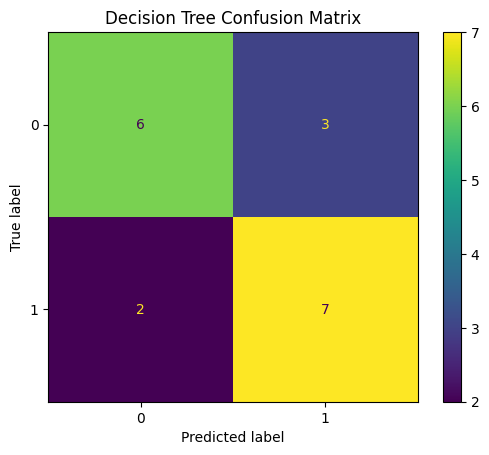

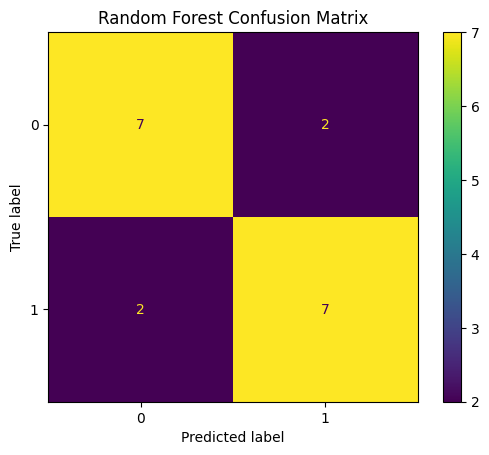

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_dt,labels=[0,1])
plt.title("Decision Tree Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_rf,labels=[0,1])
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
dt_cv = cross_val_score(dt_model, X, y, cv=5)
rf_cv = cross_val_score(rf_model, X, y, cv=5)

print("\nCross validation accuracy:")
print("Decision Tree:", dt_cv.mean())
print("Random Forest:", rf_cv.mean())


Cross validation accuracy:
Decision Tree: 0.7
Random Forest: 0.6666666666666667


In [ ]:
importance=pd.DataFrame({'feature':X.columns,'importance':rf_model.feature_importances_})
importance=importance.sort_values('importance',ascending=False)
print(importance)

           feature  importance
5       Fertilizer    0.218584
6        crop type    0.134674
1      tremperture    0.122706
0          weather    0.120867
2             soil    0.097479
7           season    0.090943
3             wind    0.086184
4         humidity    0.081661
8  irrigation_rule    0.046902


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier # Import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay

np.random.seed(42)
random.seed(42)

n_samples=300

data={
    'weather':
    np.random.choice(['sunny','cloudy','rainy'],n_samples),

    'tremperture':
    np.random.choice(['hot','mild','cool'],n_samples),

    'soil':
    np.random.choice(['dry','moist'],n_samples),

    'wind':
    np.random.choice(['weak','strong'],n_samples),

    'humidity':
    np.random.choice(['high','low'],n_samples),

    'crop types':
    np.random.choice(['cotton','wheat','rice'],n_samples),

    'irrigate':
    np.random.choice(['yes','no'],n_samples),

    'season':
    np.random.choice(['summer','winter'],n_samples)
}

df=pd.DataFrame(data)

def irrigation_rule(row):
    if row['soil'] == 'dry' and row['weather'] != 'rainy':
        base= 'yes'
    elif row['soil']=='wet':
        base='no'
    else:
        base=random.choice(['yes','no'])

    if random.random()<0.2:
        return 'no' if base=='yes'else 'yes'
    return base
df['irrigate']=df.apply(irrigation_rule,axis=1)

le=LabelEncoder()
for column in df.columns:
    if df[column].dtype=='object':
        df[column]=le.fit_transform(df[column])

x=df.drop('irrigate',axis=1)
y=df['irrigate']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)

dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train,y_train)

y_pred_dt=dt_model.predict(x_test)

rf_model=RandomForestClassifier(n_estimators=100,max_features='sqrt',random_state=42)

rf_model.fit(x_train,y_train)

y_pred_rf=rf_model.predict(x_test)

dt_accuracy=accuracy_score(y_test,y_pred_dt)
rf_accuracy=accuracy_score(y_test,y_pred_rf)

print("\naccuracy comparision:")
print("Decision Tree Accuracy:",dt_accuracy)
print("Random Forest Accuracy:",rf_accuracy)

cm_dt=confusion_matrix(y_test,y_pred_dt,labels=[0,1])
cm_rf=confusion_matrix(y_test,y_pred_rf,labels=[0,1])

print("decision tree confusion matrix:")
print(cm_dt)
print("random forest confusion matrix:")
print(cm_rf)


df_cv=cross_val_score(dt_model,x,y,cv=5)
rf_cv=cross_val_score(rf_model,x,y,cv=5)

print("cross validation accuracy:")
print("decision tree:",df_cv.mean())
print("random forest:",rf_cv.mean())









accuracy comparision:
Decision Tree Accuracy: 0.5555555555555556
Random Forest Accuracy: 0.6
decision tree confusion matrix:
[[19 15]
 [25 31]]
random forest confusion matrix:
[[16 18]
 [18 38]]
cross validation accuracy:
decision tree: 0.6
random forest: 0.6166666666666666
